In [ ]:
#과제: 5.1 데이터 이해 및 전처리 - df.head() 결과 출력1

import sys
sys.path.append("../src")

import importlib
import preprocessing
importlib.reload(preprocessing)

print(preprocessing.__file__)

df = preprocessing.load_data()
print(df.shape)
df.head()


c:\Users\정민성\Desktop\cardioProject\notebooks\../src\preprocessing.py
(920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [ ]:
#과제: 5.1 데이터 이해 및 전처리 - df.info(),head() 결과 출력2

print("=== INFO ===")
df.info()

print("=== DESCRIBE ===")
display(df.describe())

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
 14  target    920 non-null    int64  
dtypes: float64(13), int64(2)
memory usage: 107.9 KB
=== DESCRIBE ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652,0.553261
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693,0.497426
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


In [23]:
#과제: 5.1 데이터 이해 및 전처리
# -value_counts(normalize=True)로 타깃 클래스 분포를 보고하고, 그것이 평가 지표 선택에 미치는 영향을 서술
target_counts = df["target"].value_counts().sort_index()
target_ratio = df["target"].value_counts(normalize=True).sort_index()

print("클래스 개수")
print(target_counts)
print("\n클래스 비율")
print(target_ratio)

# 보기 좋게 퍼센트로도 출력
print("\n클래스 비율(%)")
print((target_ratio * 100).round(2))

# EDA에서 확인한 결과, 타깃 변수에서 심장질환이 있는 클래스(1)의 비율은 55.33%로 나타났다. 이는 극단적인 클래스 불균형은 아니지만,
# 단순 accuracy 지표만으로 모델 성능을 평가하기에는 한계가 있다.
# 심장질환 예측은 실제 질환이 있는 환자를 놓치지 않는 것이 (진양성)중요하므로, 진양성 클래스 검출 능력을 보여주는 recall(재현율)을 중점적으로 살펴봐야 한다.
# 또한 클래스별 성능을 균형 있게 반영하는 balanced accuracy와, precision 및 recall의 조화를 보여주는 F1-score를 함께 평가하는 것이 더 적절하다

클래스 개수
target
0    411
1    509
Name: count, dtype: int64

클래스 비율
target
0    0.446739
1    0.553261
Name: proportion, dtype: float64

클래스 비율(%)
target
0    44.67
1    55.33
Name: proportion, dtype: float64


In [ ]:
#결측값(열별·전체)과 이상치(boxplot + IQR 또는 z-score)를 최소한 연속형 특성(age, tresbps, chol 등등)에 대해 탐지

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

In [31]:
#결측값(열별·전체)과 이상치(boxplot + IQR 또는 z-score)를 최소한 연속형 특성(age, tresbps, chol 등등)에 대해 탐지
#결측치 확인

print("열별 결측치 개수")
print(df.isna().sum())

print("\n전체 결측치 개수")
print(df.isna().sum().sum())

print("\n열별 결측치 비율(%)")
print((df.isna().mean() * 100).round(2))

열별 결측치 개수
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64

전체 결측치 개수
1759

열별 결측치 비율(%)
age          0.00
sex          0.00
cp           0.00
trestbps     6.41
chol         3.26
fbs          9.78
restecg      0.22
thalach      5.98
exang        5.98
oldpeak      6.74
slope       33.59
ca          66.41
thal        52.83
num          0.00
target       0.00
dtype: float64


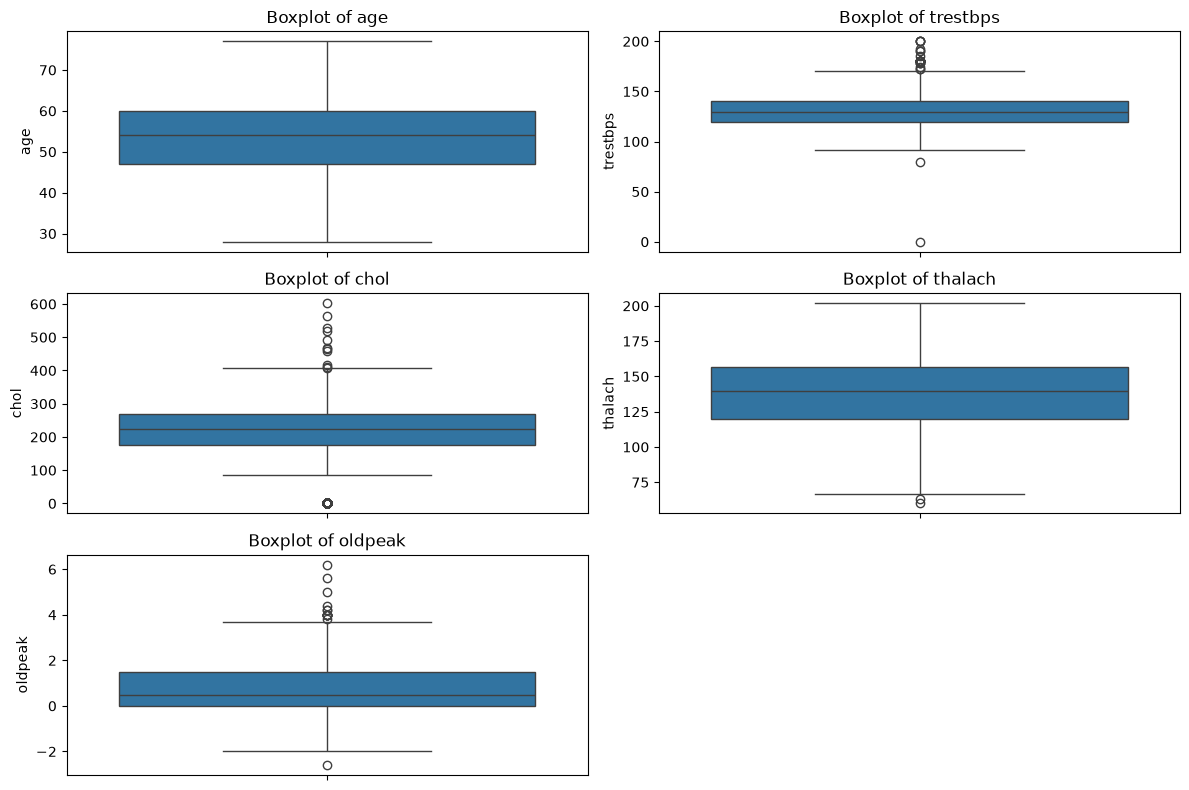

In [ ]:
#결측값(열별·전체)과 이상치(boxplot + IQR 또는 z-score)를 최소한 연속형 특성(age, tresbps, chol 등등)에 대해 탐지
#박스플롯 이상치 확인

plt.figure(figsize=(12, 8))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [ ]:
#결측값(열별·전체)과 이상치(boxplot + IQR 또는 z-score)를 최소한 연속형 특성(age, tresbps, chol 등등)에 대해 탐지
#IQR 이상치 탐지 확인

import pandas as pd

def detect_outliers_iqr(data, columns):
    outlier_summary = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (data[col] < lower_bound) | (data[col] > upper_bound)
        outlier_count = outlier_mask.sum()
        outlier_ratio = (outlier_count / len(data)) * 100

        outlier_summary.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_ratio(%)": round(outlier_ratio, 2)
        })

    return pd.DataFrame(outlier_summary)

iqr_outliers = detect_outliers_iqr(df, continuous_cols)
display(iqr_outliers)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_ratio(%)
0,age,47.0,60.0,13.0,27.50,79.50,0,0.00
1,trestbps,120.0,140.0,20.0,90.00,170.00,28,3.04
2,chol,175.0,268.0,93.0,35.50,407.50,183,19.89
3,thalach,120.0,157.0,37.0,64.50,212.50,2,0.22
4,oldpeak,0.0,1.5,1.5,-2.25,3.75,16,1.74


In [ ]:
#결측값(열별·전체)과 이상치(boxplot + IQR 또는 z-score)를 최소한 연속형 특성(age, tresbps, chol 등등)에 대해 탐지
#결과

# 연속형 변수(age, trestbps, chol, thalach, oldpeak)에 대해 boxplot과 IQR 기준을 사용하여 이상치를 탐지하였다.
# 일부 변수에서 IQR 범위를 벗어나는 값이 확인되었으나(ex. chol에서 outlier_ratio의 비율:19.89%와 박스플롯의 울타리 벗어나는 O의 개수들), 의료 데이터에서는 이러한 값이 단순 입력 오류가 아니라 실제 환자 상태를 반영할 가능성도 있으므로
# 무조건적으로 제거하지 않고 분포와 모델 성능에 미치는 영향을 함께 고려하였다.

In [7]:
#결측값(컬럼별로 삭제 vs. 평균/중앙값/KNN 대치를 정당화), 이상치, 빈 컬럼, 중복을 처리하는 전처리 파이프라인 구성
#preprocessing.py에 파이프라인 구현했습니다.
#1.데이터 로드

import sys
sys.path.append("../src")

import importlib
import preprocessing
importlib.reload(preprocessing)

from preprocessing import load_data_from_ucimerged, make_xy, PreprocessConfig, build_preprocessing_pipeline

df = load_data_from_ucimerged()
print(df.shape)
df.head()

(920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [10]:
#결측값(컬럼별로 삭제 vs. 평균/중앙값/KNN 대치를 정당화), 이상치, 빈 컬럼, 중복을 처리하는 전처리 파이프라인 구성
#preprocessing.py에 파이프라인 구현했습니다.
#2.결측/중복/빈 컬럼 “탐지 결과” 출력


# 결측(열별/전체)
display(df.isna().sum().sort_values(ascending=False))
print("전체 결측 개수:", int(df.isna().sum().sum()))

# 중복 행 개수
print("중복 행 개수:", int(df.duplicated().sum()))

# 완전 빈 컬럼(있으면)
empty_cols = df.columns[df.isna().all()].tolist()
print("완전 빈 컬럼:", empty_cols)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalach      55
exang        55
chol         30
restecg       2
cp            0
sex           0
age           0
num           0
target        0
dtype: int64

전체 결측 개수: 1759
중복 행 개수: 2
완전 빈 컬럼: []


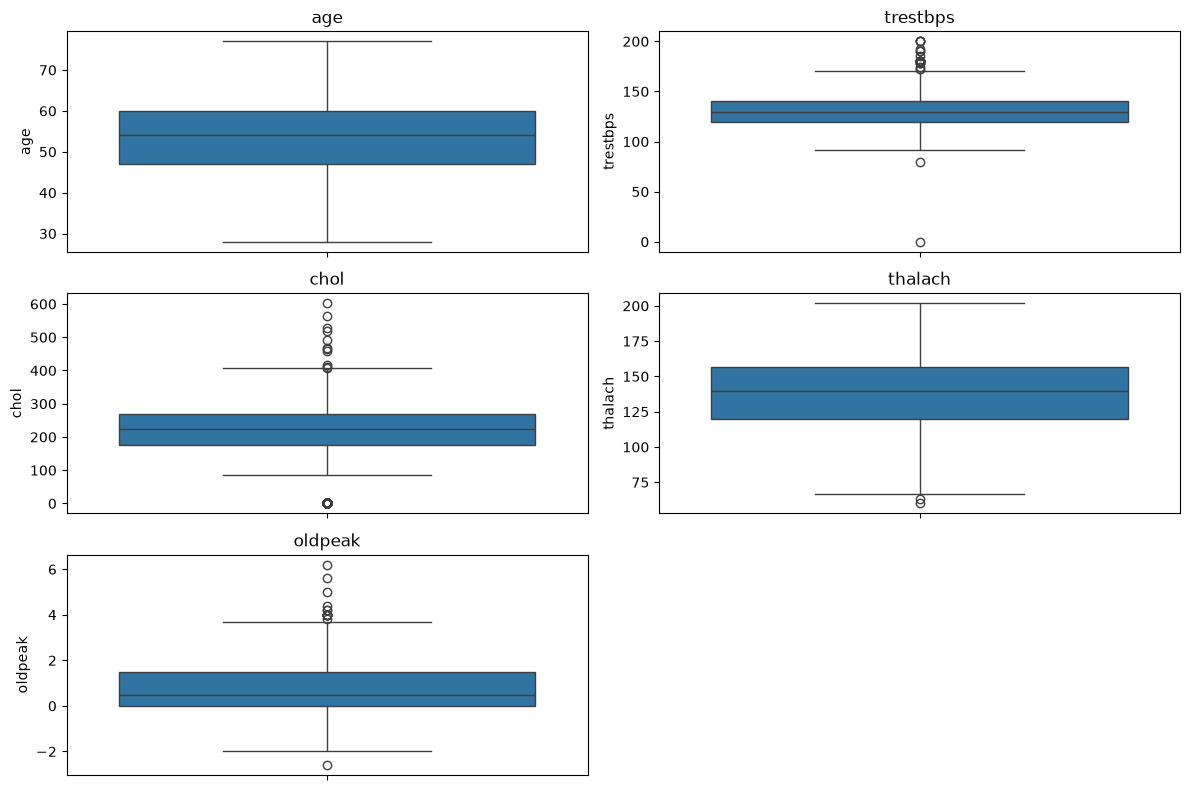

,feature,lower,upper,outlier_count,outlier_ratio(%)
0,age,27.50,79.50,0,0.00
1,trestbps,90.00,170.00,28,3.04
2,chol,35.50,407.50,183,19.89
3,thalach,64.50,212.50,2,0.22
4,oldpeak,-2.25,3.75,16,1.74


In [9]:
#결측값(컬럼별로 삭제 vs. 평균/중앙값/KNN 대치를 정당화), 이상치, 빈 컬럼, 중복을 처리하는 전처리 파이프라인 구성
#preprocessing.py에 파이프라인 구현했습니다.
#3.이상치 탐지(박스플롯 + IQR 요약)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

def iqr_summary(data, cols):
    rows = []
    for c in cols:
        q1 = data[c].quantile(0.25)
        q3 = data[c].quantile(0.75)
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        out = ((data[c] < lo) | (data[c] > hi)).sum()
        rows.append([c, lo, hi, int(out), round(out/len(data)*100, 2)])
    return pd.DataFrame(rows, columns=["feature", "lower", "upper", "outlier_count", "outlier_ratio(%)"])

display(iqr_summary(df, continuous_cols))

삭제 VS 대치 무엇을 할 것인가..

-ca, thal은 결측률이 50% 이상이라 삭제 후보에 두었지만 두 변수는 실제 이 도메인에서 중요한 변수로 작용한다는 정보가 있어서 추후 삭제 버전 vs 대체 버전으로 교차 비교해볼 것입니다.
-slope는 결측이 많지만(33%) 의미 있는 변수일 수 있어 최빈값 대치했습니다.
-수치형은 이상치 존재 가능성이 있어 평균보다 중앙값 대치가 안정적이라 판단했습니다.
-이상치는 의료 데이터 특성상 완전 오류로 단정하기 어려워 삭제 대신 IQR 클리핑 적용했습니다.
-중복 행은 정보가 추가되지 않으므로 제거했습니다.

In [5]:
import sys
sys.path.append("../src")

import preprocessing
print(preprocessing.__file__)
print(dir(preprocessing))

c:\Users\정민성\Desktop\cardioProject\notebooks\../src\preprocessing.py
['BaseEstimator', 'ColumnTransformer', 'Dict', 'DropDuplicates', 'DropEmptyOrHighMissingColumns', 'IQRClipper', 'KNNImputer', 'List', 'OneHotEncoder', 'Optional', 'Pipeline', 'PreprocessConfig', 'SimpleImputer', 'StandardScaler', 'TransformerMixin', 'Tuple', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'build_preprocessing_pipeline', 'dataclass', 'load_data_from_ucimerged', 'make_xy', 'np', 'os', 'pd']


EDA를 통해 이 데이터셋은 심장질환 여부를 예측하는 이진 분류 문제이며, target=1의 비율이 약 55.33% 로 나타나 완전한 균형 데이터는 아니지만 극단적인 불균형도 아닌 상태임을 확인했습니다. 또한 head(), info(), describe()와 결측치 분석을 통해 slope, ca, thal에서 결측이 집중되어 있음을 확인했고, 특히 ca와 thal은 결측 비율(50%이상)이 매우 높아 그대로 사용하는 데 한계가 있음을 알 수 있었습니다. 연속형 변수(trestbps, chol, thalach, oldpeak)에 대해서는 boxplot과 IQR 기준으로 이상치 후보가 존재함을 확인했습니다.(age는 이상치 없음)

이 결과를 바탕으로 전처리에서는 타깃 원본 컬럼 num을 제거하여 데이터 누수를 방지하고, 수치형 변수는 중앙값(median) 대치와 ca와 thal 같은 이상치 변수들의 크기와 범위에 영향을 받지 않도록 표준정규분포 평균0, 표준편차가 1로 변환되는 스케일링(StandardScaler)을 적용하도록 구성했습니다. 중앙값 대치를 선택한 이유는 이상치의 영향을 평균보다 덜 받기 때문입니다. 범주형 변수는 최빈값 대치와 원-핫 인코딩을 적용했습니다. 결측률이 지나치게 높은 50%대의 ca와 thal 컬럼은 삭제 후보로 두고, 중복 행과 빈 컬럼은 제거하도록 파이프라인에 포함했습니다. 또한 이상치는 무조건 삭제하지 않고 IQR 기반 클리핑(clipping) 으로 처리하여, 극단값이 실제 임상 정보를 반영할 가능성을 보존하면서도 모델 안정성을 높이도록 했습니다.